<a href="https://colab.research.google.com/github/ale3665/ML-Project-Food-Insecurity-Predictions/blob/main/ML_Project_Food_Insecurity_Predictions_(Final).ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Food Insecurity Prediction - Notebook**

In [ ]:
# Step 1: Install and Import Necessary Libraries
%matplotlib inline
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

from google.colab import files
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MinMaxScaler
from sklearn.linear_model import LinearRegression, LogisticRegression
from sklearn.tree import DecisionTreeRegressor, DecisionTreeClassifier
from sklearn.ensemble import RandomForestRegressor, RandomForestClassifier
from sklearn.neighbors import KNeighborsRegressor, KNeighborsClassifier
from sklearn.svm import SVR, SVC
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

In [ ]:
# Step 2: Upload Excel File
print("Please upload the combined dataset in Excel format.")
uploaded = files.upload()

# Load uploaded Excel file
combined_data = None
for filename in uploaded.keys():
    if filename.endswith(".xlsx"):
        combined_path = filename
        combined_data = pd.read_excel(combined_path, sheet_name=None)
        first_sheet = list(combined_data.keys())[0]
        combined_data = combined_data[first_sheet]
        print("Combined dataset loaded successfully.")
    else:
        print(f"Uploaded file {filename} is not an Excel file.")

Please upload the combined dataset in Excel format.


Saving COMBINED DATA (USDA & FEEDING AMERICA).xlsx to COMBINED DATA (USDA & FEEDING AMERICA) (1).xlsx
Combined dataset loaded successfully.


In [ ]:
# Step 3: Data Inspection & Cleaning
print("Dataset Info:")
print(combined_data.info())

print("Missing values:")
print(combined_data.isnull().sum())

# Fill missing values
combined_data.fillna(combined_data.median(), inplace=True)

Dataset Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 207 entries, 0 to 206
Data columns (total 12 columns):
 #   Column                                                      Non-Null Count  Dtype  
---  ------                                                      --------------  -----  
 0   Year                                                        207 non-null    int64  
 1   Overall Food Insecurity Rate                                207 non-null    float64
 2   # of Food Insecure Persons Overall                          207 non-null    int64  
 3   Food Insecurity Rate among Black Persons (all ethnicities)  167 non-null    float64
 4   Food Insecurity Rate among Hispanic Persons (any race)      191 non-null    float64
 5   Food Insecurity Rate among White, non-Hispanic Persons      206 non-null    float64
 6   Child Food Insecurity Rate                                  207 non-null    float64
 7   # of Food Insecure Children                                 207 non-null   

In [ ]:
# Step 4: Define Features and Target
features = combined_data.drop(columns=['Year', 'Overall Food Insecurity Rate'])
target_regression = combined_data['Overall Food Insecurity Rate']

X_train, X_test, y_train, y_test = train_test_split(features, target_regression, test_size=0.2, random_state=42)

# Step 5: Normalize Features
scaler = MinMaxScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

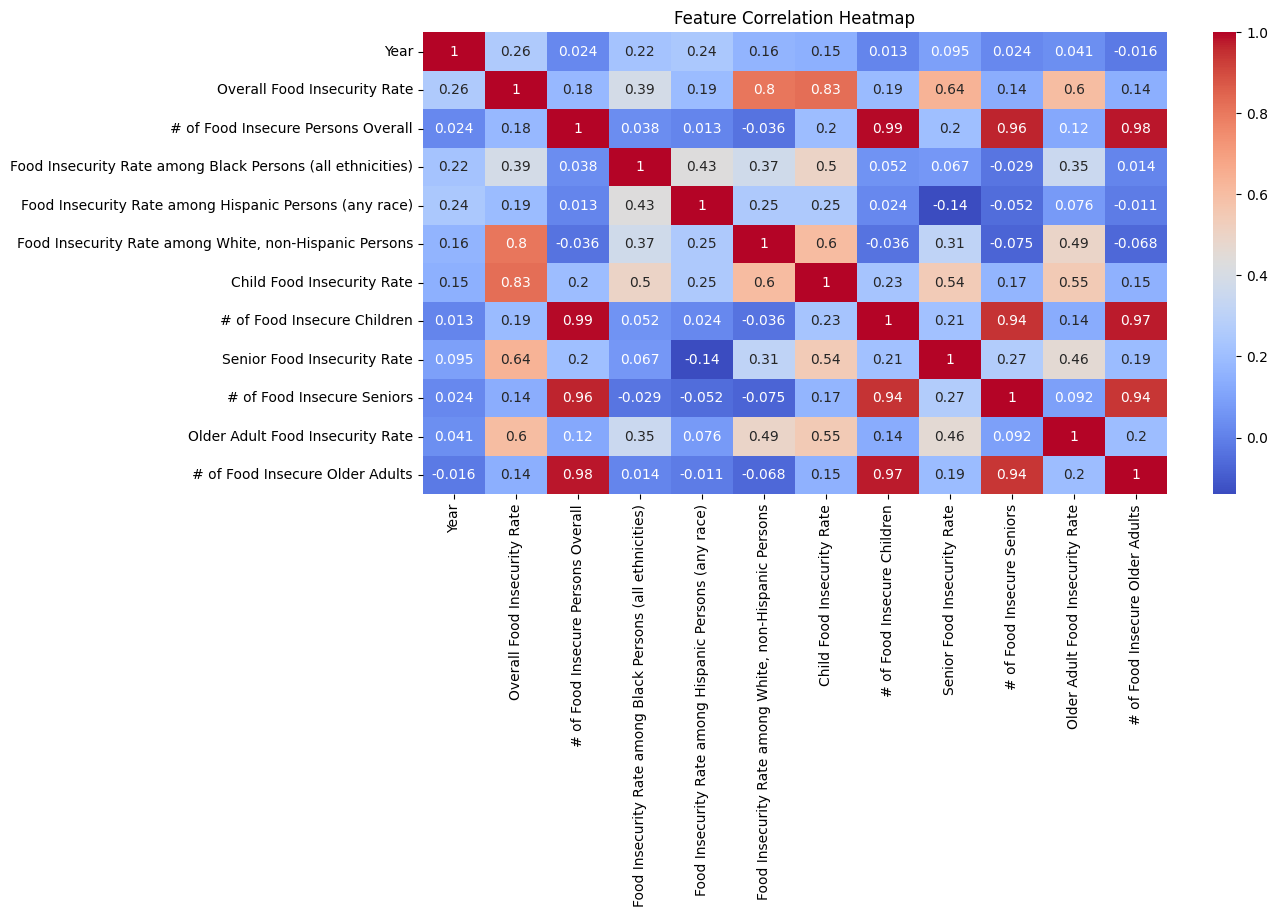

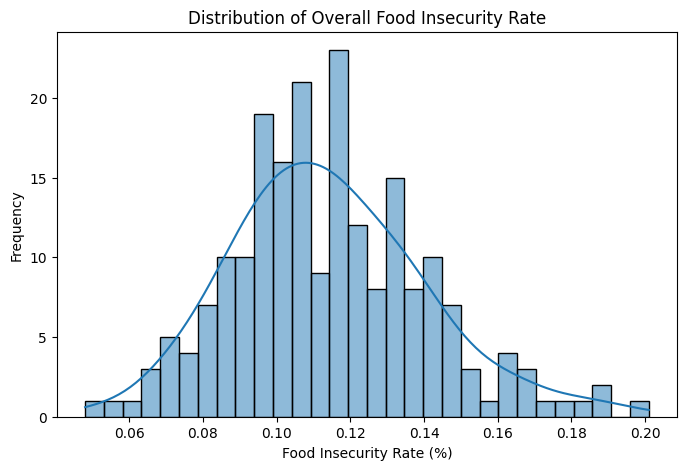

In [ ]:
# Step 6: Correlation Heatmap & Distribution
plt.figure(figsize=(12,6))
sns.heatmap(combined_data.corr(), annot=True, cmap="coolwarm")
plt.title("Feature Correlation Heatmap")
plt.show()

plt.figure(figsize=(8,5))
sns.histplot(combined_data['Overall Food Insecurity Rate'], kde=True, bins=30)
plt.title("Distribution of Overall Food Insecurity Rate")
plt.xlabel("Food Insecurity Rate (%)")
plt.ylabel("Frequency")
plt.show()

In [ ]:
# Step 7: Regression Models
regressors = {
    'Linear Regression': LinearRegression(),
    'Decision Tree': DecisionTreeRegressor(random_state=42),
    'Random Forest': RandomForestRegressor(random_state=42),
    'KNN': KNeighborsRegressor(),
    'SVR': SVR()
}

regression_results = []

for name, model in regressors.items():
    model.fit(X_train_scaled, y_train)
    preds = model.predict(X_test_scaled)
    mae = mean_absolute_error(y_test, preds)
    rmse = np.sqrt(mean_squared_error(y_test, preds))
    r2 = r2_score(y_test, preds)

    print(f"{name} → MAE: {mae:.4f}, RMSE: {rmse:.4f}, R²: {r2:.4f}")

    regression_results.append({'Model': name, 'MAE': mae, 'RMSE': rmse, 'R2 Score': r2})

regression_df = pd.DataFrame(regression_results)
display(regression_df)

Linear Regression → MAE: 0.0066, RMSE: 0.0117, R²: 0.8609
Decision Tree → MAE: 0.0107, RMSE: 0.0209, R²: 0.5596
Random Forest → MAE: 0.0079, RMSE: 0.0157, R²: 0.7494
KNN → MAE: 0.0095, RMSE: 0.0158, R²: 0.7456
SVR → MAE: 0.0252, RMSE: 0.0319, R²: -0.0286


,Model,MAE,RMSE,R2 Score
0,Linear Regression,0.006636,0.011717,0.860923
1,Decision Tree,0.010738,0.020852,0.559562
2,Random Forest,0.007913,0.015729,0.749389
3,KNN,0.009510,0.015847,0.745599
4,SVR,0.025214,0.031865,-0.028558


In [ ]:
# Step 8: Binary Classification Preparation
target_classification = combined_data['Overall Food Insecurity Rate'].apply(lambda x: 'High' if x > 9 else 'Low')

print("\nClass distribution (binary):")
print(target_classification.value_counts())

X_train_cls, X_test_cls, y_train_cls, y_test_cls = train_test_split(
    features, target_classification, test_size=0.2, stratify=target_classification, random_state=42
)

X_train_scaled_cls = scaler.fit_transform(X_train_cls)
X_test_scaled_cls = scaler.transform(X_test_cls)

# Step 10: Classification Models
classifiers = {
    'Logistic Regression': LogisticRegression(),
    'Decision Tree': DecisionTreeClassifier(random_state=42),
    'Random Forest': RandomForestClassifier(random_state=42),
    'KNN': KNeighborsClassifier(),
    'SVM': SVC()
}

classification_results = []

for name, model in classifiers.items():
  if len(set(y_train_cls)) < 2:
    print(f"Skipping {name} due to insufficient class diversity in training set.")
    continue
    model.fit(X_train_scaled_cls, y_train_cls)
    preds = model.predict(X_test_scaled_cls)
    acc = accuracy_score(y_test_cls, preds)
    precision = precision_score(y_test_cls, preds, pos_label='High')
    recall = recall_score(y_test_cls, preds, pos_label='High')
    f1 = f1_score(y_test_cls, preds, pos_label='High')

    print(f"{name} → Accuracy: {acc:.4f}, Precision: {precision:.4f}, Recall: {recall:.4f}, F1: {f1:.4f}")

    classification_results.append({'Model': name, 'Accuracy': acc, 'Precision': precision, 'Recall': recall, 'F1 Score': f1})

classification_df = pd.DataFrame(classification_results)
display(classification_df)


Class distribution (binary):
Overall Food Insecurity Rate
Low    207
Name: count, dtype: int64
Skipping Logistic Regression due to insufficient class diversity in training set.
Skipping Decision Tree due to insufficient class diversity in training set.
Skipping Random Forest due to insufficient class diversity in training set.
Skipping KNN due to insufficient class diversity in training set.
Skipping SVM due to insufficient class diversity in training set.


""


In [ ]:
# Step 9: Classification Models (with try-except and class checks)
print("\nClass distribution before split:")
print(target_classification.value_counts())

X_train_cls, X_test_cls, y_train_cls, y_test_cls = train_test_split(
    features, target_classification, test_size=0.2, stratify=target_classification, random_state=42
)

print("\nClass distribution in training set:")
print(y_train_cls.value_counts())

X_train_scaled_cls = scaler.fit_transform(X_train_cls)
X_test_scaled_cls = scaler.transform(X_test_cls)

# Classification Models
classifiers = {
    'Logistic Regression': LogisticRegression(),
    'Decision Tree': DecisionTreeClassifier(random_state=42),
    'Random Forest': RandomForestClassifier(random_state=42),
    'KNN': KNeighborsClassifier(),
    'SVM': SVC()
}

classification_results = []

for name, model in classifiers.items():
    try:
        model.fit(X_train_scaled_cls, y_train_cls)
        preds = model.predict(X_test_scaled_cls)

        acc = accuracy_score(y_test_cls, preds)
        precision = precision_score(y_test_cls, preds, pos_label='High')
        recall = recall_score(y_test_cls, preds, pos_label='High')
        f1 = f1_score(y_test_cls, preds, pos_label='High')

        classification_results.append({
            'Model': name,
            'Accuracy': acc,
            'Precision': precision,
            'Recall': recall,
            'F1 Score': f1
        })

        print(f"{name} → ✅ Trained Successfully")

    except ValueError as e:
        print(f"{name} → ❌ Skipped due to error: {e}")

classification_df = pd.DataFrame(classification_results)
display(classification_df)


Class distribution before split:
Overall Food Insecurity Rate
Low    207
Name: count, dtype: int64

Class distribution in training set:
Overall Food Insecurity Rate
Low    165
Name: count, dtype: int64
Logistic Regression → ❌ Skipped due to error: This solver needs samples of at least 2 classes in the data, but the data contains only one class: 'Low'
Decision Tree → ✅ Trained Successfully
Random Forest → ✅ Trained Successfully
KNN → ✅ Trained Successfully
SVM → ❌ Skipped due to error: The number of classes has to be greater than one; got 1 class


,Model,Accuracy,Precision,Recall,F1 Score
0,Decision Tree,1.0,0.0,0.0,0.0
1,Random Forest,1.0,0.0,0.0,0.0
2,KNN,1.0,0.0,0.0,0.0


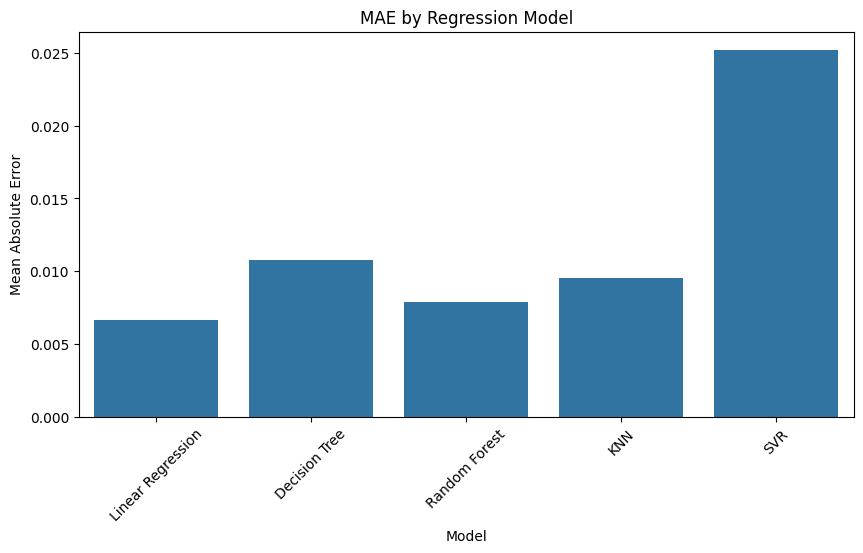

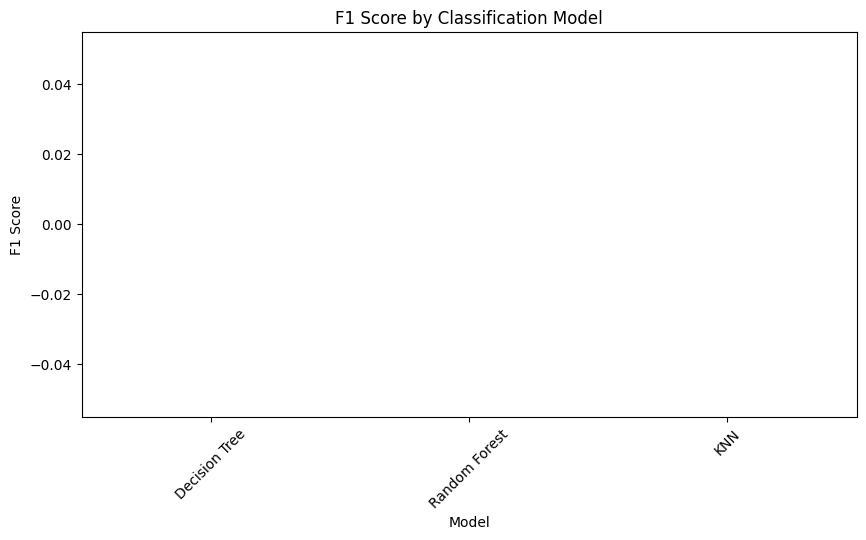

In [ ]:
# Step 10: Bar Charts
plt.figure(figsize=(10, 5))
sns.barplot(data=regression_df, x='Model', y='MAE')
plt.title("MAE by Regression Model")
plt.ylabel("Mean Absolute Error")
plt.xticks(rotation=45)
plt.show()

plt.figure(figsize=(10, 5))
sns.barplot(data=classification_df, x='Model', y='F1 Score')
plt.title("F1 Score by Classification Model")
plt.ylabel("F1 Score")
plt.xticks(rotation=45)
plt.show()